<a href="https://colab.research.google.com/github/jishnujs1990/Study/blob/master/ML_Assignment_5_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#The objective of this assessment is to evaluate your understanding and ability to apply clustering
#techniques to a real-world dataset.

In [2]:
#Dataset: Use the Iris dataset available in the sklearn library.

Loading and Preprocessing (1 mark)
● Load the Iris dataset from sklearn.
● Drop the species column since this is a clustering problem.

In [3]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
import pandas as pd
import numpy as np

# Load the Iris dataset
iris = load_iris()
X = iris.data
feature_names = iris.feature_names

# Convert to DataFrame and drop the species column (implicit by only loading features)
df = pd.DataFrame(X, columns=feature_names)
print("Dataset Preprocessed. Shape:", df.shape)
df.head()

Dataset Preprocessed. Shape: (150, 4)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


Clustering Algorithm Implementation (8 marks): Implement the following two clustering algorithms:
1. KMeans Clustering (4 marks) :
● Provide a brief description of how KMeans clustering works.
● Explain why KMeans clustering might be suitable for the Iris dataset.
● Apply KMeans clustering to the preprocessed Iris dataset and visualize the clusters.

**Description:**
KMeans partitions data into k distinct clusters. It randomly initializes k cluster centers (centroids), assigns each data point to its nearest centroid based on distance (usually Euclidean), updates the centroids by taking the mean of all points in that cluster, and repeats this process until the centroids stop moving.

**Why this is suitable?**
KMeans is highly suitable for the Iris dataset because the data has low dimensionality (4 features) and a small sample size (150 rows).

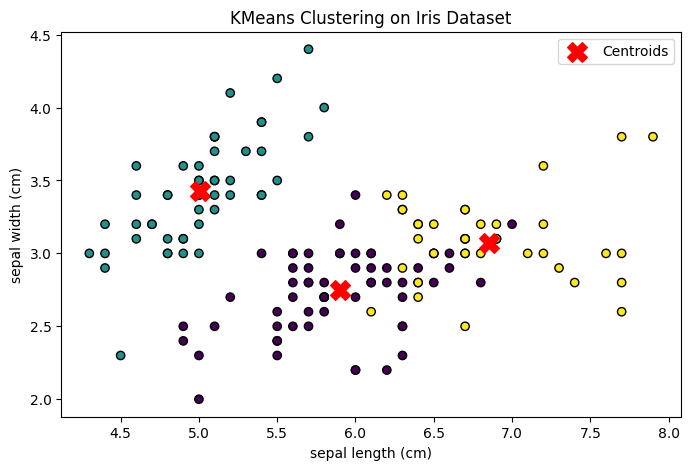

In [12]:
from sklearn.cluster import KMeans

# Initialize and fit KMeans for 3 clusters (since Iris naturally has 3 species)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(df)

# Visualize the clusters (using Sepal Length vs Sepal Width)
plt.figure(figsize=(8, 5))
plt.scatter(
    df.iloc[:, 0], df.iloc[:, 1], c=kmeans_labels, cmap="viridis", edgecolor="k"
)

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=200,
    c="red",
    marker="X",
    label="Centroids",
)
plt.title("KMeans Clustering on Iris Dataset")
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.legend()
plt.show()

2. Hierarchical Clustering (4 marks):
● Provide a brief description of how Hierarchical clustering works.
● Explain why Hierarchical clustering might be suitable for the Iris dataset.
● Apply Hierarchical clustering to the preprocessed Iris dataset and visualize the clusters.

**Description**
Hierarchical clustering builds a tree-like hierarchy of clusters. Bottom-up approach,every data point starts as its own individual cluster.The algorithm iteratively merges the closest pair of clusters based on a linkage criteria until all points are grouped into a single root cluster.

** Suitability **
Hierarchical clustering fits the Iris dataset because it doesn't require pre-specifying the number of clusters to understand the structure.

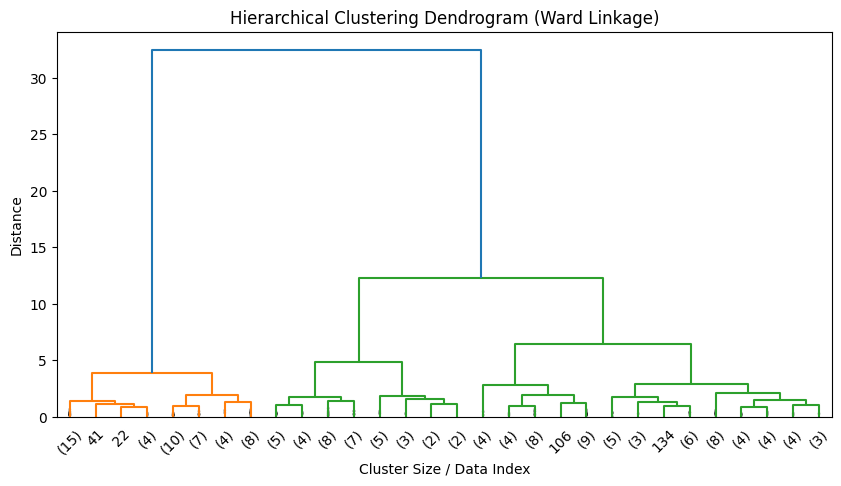

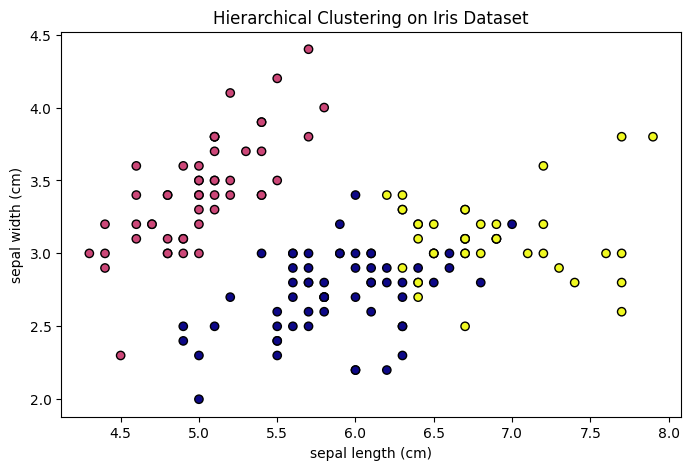

In [14]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
linked = linkage(df, method="ward")

# Plot the graph diagram
plt.figure(figsize=(10, 5))
dendrogram(linked, truncate_mode="lastp", p=30, leaf_rotation=45, show_contracted=True)
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)")
plt.xlabel("Cluster Size / Data Index")
plt.ylabel("Distance")
plt.show()

agg_clustering = AgglomerativeClustering(n_clusters=3, linkage="ward")
hierarchical_labels = agg_clustering.fit_predict(df)

# Visualize the clusters (using Sepal Length vs Sepal Width)
plt.figure(figsize=(8, 5))
plt.scatter(
    df.iloc[:, 0],
    df.iloc[:, 1],
    c=hierarchical_labels,
    cmap="plasma",
    edgecolor="k",
)
plt.title("Hierarchical Clustering on Iris Dataset")
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.show()